In [ ]:
# الخطوة 1: استيراد المكتبات وتحميل البيانات

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ تم استيراد المكتبات بنجاح")

# تحميل ملفات البيانات
try:
    X = pd.read_csv('X_train_2025.csv')
    y = pd.read_csv('y_train_2025.csv')
    print(f"\n✅ تم تحميل X_train_2025.csv: {X.shape[0]} صفوف، {X.shape[1]} أعمدة")
    print(f"✅ تم تحميل y_train_2025.csv: {y.shape[0]} صفوف، {y.shape[1]} أعمدة")
except FileNotFoundError as e:
    print(f"\n❌ خطأ: الملف غير موجود. تأكد من وجود الملفات في مجلد العمل الحالي.")
    print("المجلد الحالي:", os.getcwd())
    raise

# عرض أول 5 صفوف من بيانات الميزات
print("\n--- أول 5 صفوف من X (الميزات) ---")
display(X.head())

# عرض أول 5 صفوف من الهدف
print("\n--- أول 5 صفوف من y (الهدف) ---")
display(y.head())

# التحقق من وجود عمود recordid للتأكد من التطابق
print("\n--- التحقق من تطابق الـ recordid بين X و y ---")
print("هل recordid في X متطابق مع recordid في y؟", (X['recordid'] == y['recordid']).all())

✅ تم استيراد المكتبات بنجاح

✅ تم تحميل X_train_2025.csv: 3600 صفوف، 120 أعمدة
✅ تم تحميل y_train_2025.csv: 3600 صفوف، 1 أعمدة

--- أول 5 صفوف من X (الميزات) ---


,recordid,SAPS-I,SOFA,Age,Gender,Height,Weight,CCU,CSRU,SICU,...,Platelets_last,TroponinI_last,TroponinT_last,WBC_last,Weight_last,pH_last,MechVentStartTime,MechVentDuration,MechVentLast8Hour,UrineOutputSum
0,137517,-1,2,56.0,0.0,NaN,79.6,0,0,0,...,444.0,NaN,NaN,7.3,79.6,NaN,NaN,NaN,NaN,NaN
1,145680,10,3,72.0,1.0,NaN,70.0,0,0,0,...,82.0,NaN,0.07,2.4,70.0,7.48,NaN,NaN,NaN,NaN
2,138649,-1,8,81.0,0.0,NaN,NaN,0,0,0,...,211.0,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN
3,149075,16,8,56.0,1.0,180.3,94.8,1,0,0,...,204.0,NaN,NaN,11.4,98.9,7.44,1128.0,470.0,0.0,4.0
4,141408,14,7,52.0,1.0,182.9,120.6,0,1,0,...,352.0,NaN,NaN,9.0,120.6,7.43,143.0,2580.0,1.0,16.0



--- أول 5 صفوف من y (الهدف) ---


,In-hospital_death
0,0
1,0
2,0
3,0
4,0



--- التحقق من تطابق الـ recordid بين X و y ---


KeyError: 'recordid'

=== معلومات عامة عن البيانات ===
عدد الصفوف: 3600, عدد الأعمدة: 121

=== أنواع البيانات ===
float64    114
int64        7
Name: count, dtype: int64

=== توزيع الهدف In-hospital_death ===
In-hospital_death
0    3097
1     503
Name: count, dtype: int64
In-hospital_death
0    86.027778
1    13.972222
Name: proportion, dtype: float64


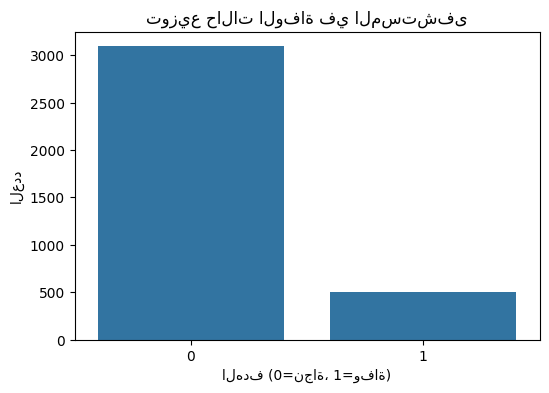


=== القيم المفقودة (أعلى 20 عمود) ===
TroponinI_last       3425
TroponinI_first      3425
Cholesterol_first    3325
Cholesterol_last     3325
TroponinT_first      2814
TroponinT_last       2814
RespRate_highest     2606
RespRate_lowest      2606
RespRate_first       2606
RespRate_last        2606
RespRate_median      2606
Albumin_first        2128
Albumin_last         2128
ALP_last             2068
ALP_first            2068
Bilirubin_last       2041
ALT_first            2041
Bilirubin_first      2041
ALT_last             2041
AST_first            2038
dtype: int64


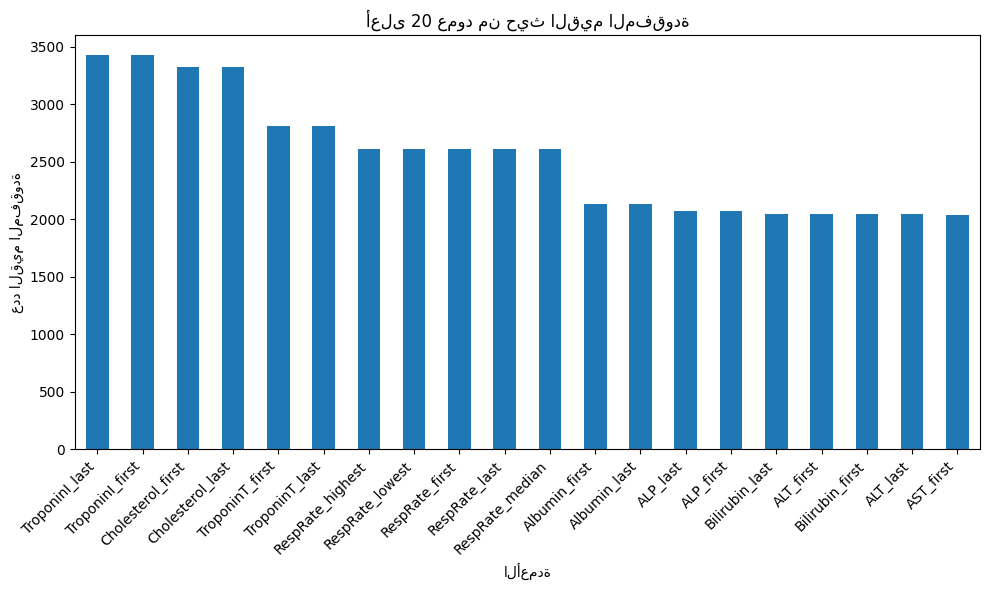


عدد الأعمدة الرقمية: 121
عدد الأعمدة الفئوية: 0
لا توجد أعمدة فئوية، جميع الأعمدة رقمية.

=== إحصائيات وصفية لبعض المتغيرات الهامة ===


,Age,SAPS-I,SOFA,HR_first,HR_last,GCS_first,GCS_last,MAP_first,MAP_last
count,3600.000000,3600.000000,3600.000000,3535.000000,3535.000000,3535.000000,3535.000000,2498.000000,2498.000000
mean,64.462778,14.187500,6.311111,89.686280,85.932673,10.090240,12.396322,85.253002,82.730985
std,17.630796,6.061105,4.191431,20.344884,17.446109,4.893033,3.594380,27.550995,19.594827
min,15.000000,-1.000000,-1.000000,33.000000,40.000000,3.000000,3.000000,1.000000,2.000000
25%,53.000000,11.000000,3.000000,76.000000,73.000000,5.500000,10.000000,71.000000,71.000000
50%,67.000000,15.000000,6.000000,88.000000,85.000000,11.000000,15.000000,82.000000,80.000000
75%,78.000000,18.000000,9.000000,102.000000,97.000000,15.000000,15.000000,95.000000,92.000000
max,90.000000,34.000000,22.000000,216.000000,185.000000,15.000000,15.000000,294.000000,289.000000


In [ ]:
# الخطوة 2: التحليل الاستكشافي للبيانات (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# دمج X و y معاً (بافتراض نفس الترتيب)
df = X.copy()
df['In-hospital_death'] = y['In-hospital_death'].values

print("=== معلومات عامة عن البيانات ===")
print(f"عدد الصفوف: {df.shape[0]}, عدد الأعمدة: {df.shape[1]}")
print("\n=== أنواع البيانات ===")
print(df.dtypes.value_counts())

# توزيع الهدف
print("\n=== توزيع الهدف In-hospital_death ===")
print(df['In-hospital_death'].value_counts())
print(df['In-hospital_death'].value_counts(normalize=True) * 100)

# رسم توزيع الهدف
plt.figure(figsize=(6,4))
sns.countplot(x='In-hospital_death', data=df)
plt.title('توزيع حالات الوفاة في المستشفى')
plt.xlabel('الهدف (0=نجاة، 1=وفاة)')
plt.ylabel('العدد')
plt.show()

# القيم المفقودة
print("\n=== القيم المفقودة (أعلى 20 عمود) ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(20))

# رسم بياني لأهم 20 عمود من حيث القيم المفقودة
plt.figure(figsize=(10,6))
missing.head(20).plot(kind='bar')
plt.title('أعلى 20 عمود من حيث القيم المفقودة')
plt.xlabel('الأعمدة')
plt.ylabel('عدد القيم المفقودة')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# تحديد الأعمدة الرقمية والفئوية
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nعدد الأعمدة الرقمية: {len(numerical_cols)}")
print(f"عدد الأعمدة الفئوية: {len(categorical_cols)}")
if categorical_cols:
    print("الأعمدة الفئوية:", categorical_cols)
else:
    print("لا توجد أعمدة فئوية، جميع الأعمدة رقمية.")

# إحصائيات وصفية لبعض المتغيرات الهامة (إن وجدت)
important_cols = ['Age', 'SAPS-I', 'SOFA', 'HR_first', 'HR_last', 'GCS_first', 'GCS_last', 'MAP_first', 'MAP_last']
available_important = [col for col in important_cols if col in df.columns]
if available_important:
    print("\n=== إحصائيات وصفية لبعض المتغيرات الهامة ===")
    display(df[available_important].describe())
else:
    print("\nلا توجد المتغيرات المحددة في البيانات.")


In [ ]:
# الخطوة 3: المعالجة المسبقة للبيانات

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# إعادة تحميل البيانات للتأكد من النظافة (اختياري)
X = pd.read_csv('X_train_2025.csv')
y = pd.read_csv('y_train_2025.csv')

# 1. حذف عمود recordid من X (ويوجد أيضاً في y لكنه ليس هدفاً)
if 'recordid' in X.columns:
    X = X.drop(columns=['recordid'])
    print("✅ تم حذف عمود recordid من X.")

# 2. تحويل القيم -1 إلى NaN في الأعمدة التي قد تحتويها (خاصة SAPS-I و SOFA)
cols_with_neg1 = ['SAPS-I', 'SOFA']  # يمكن إضافة المزيد إذا لاحظت
for col in cols_with_neg1:
    if col in X.columns:
        X[col] = X[col].replace(-1, np.nan)
        print(f"✅ تم تحويل -1 إلى NaN في عمود {col}")

# 3. حساب نسبة المفقودات لكل عمود
missing_ratio = (X.isnull().sum() / len(X)) * 100
print("\n--- نسبة القيم المفقودة (أعلى 10 أعمدة) ---")
print(missing_ratio.sort_values(ascending=False).head(10))

# إزالة الأعمدة التي بها نسبة مفقودات > 80%
high_missing_cols = missing_ratio[missing_ratio > 80].index.tolist()
if high_missing_cols:
    print(f"\nسيتم إزالة {len(high_missing_cols)} عمود بنسبة مفقودات > 80%: {high_missing_cols[:5]}...")
    X = X.drop(columns=high_missing_cols)
else:
    print("\nلا توجد أعمدة بنسبة مفقودات > 80%.")

print(f"\nشكل البيانات بعد الحذف: {X.shape}")

# 4. تقسيم البيانات إلى تدريب واختبار (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(
    X, y['In-hospital_death'], test_size=0.2, random_state=42, stratify=y['In-hospital_death']
)

print(f"\n✅ تم التقسيم:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape[0]} عينة (نسبة الوفاة: {y_train.mean()*100:.2f}%)")
print(f"   y_test: {y_test.shape[0]} عينة (نسبة الوفاة: {y_test.mean()*100:.2f}%)")

# حفظ المتغيرات الهامة للخطوات القادمة
# تحديد الأعمدة الرقمية (كلها رقمية الآن)
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nعدد الأعمدة الرقمية المتبقية: {len(numerical_cols)}")

✅ تم حذف عمود recordid من X.
✅ تم تحويل -1 إلى NaN في عمود SAPS-I
✅ تم تحويل -1 إلى NaN في عمود SOFA

--- نسبة القيم المفقودة (أعلى 10 أعمدة) ---
TroponinI_last       95.138889
TroponinI_first      95.138889
Cholesterol_first    92.361111
Cholesterol_last     92.361111
TroponinT_first      78.166667
TroponinT_last       78.166667
RespRate_first       72.388889
RespRate_highest     72.388889
RespRate_median      72.388889
RespRate_lowest      72.388889
dtype: float64

سيتم إزالة 4 عمود بنسبة مفقودات > 80%: ['Cholesterol_first', 'TroponinI_first', 'Cholesterol_last', 'TroponinI_last']...

شكل البيانات بعد الحذف: (3600, 115)

✅ تم التقسيم:
   X_train: (2880, 115)
   X_test: (720, 115)
   y_train: 2880 عينة (نسبة الوفاة: 13.96%)
   y_test: 720 عينة (نسبة الوفاة: 14.03%)

عدد الأعمدة الرقمية المتبقية: 115


scale_pos_weight = 6.16
تدريب النموذج...
✅ تم التدريب

=== أداء النموذج الأساسي (Baseline) ===
AUC-ROC: 0.8268

تقرير التصنيف:
              precision    recall  f1-score   support

        نجاة       0.90      0.94      0.92       619
        وفاة       0.50      0.35      0.41       101

    accuracy                           0.86       720
   macro avg       0.70      0.64      0.66       720
weighted avg       0.84      0.86      0.85       720



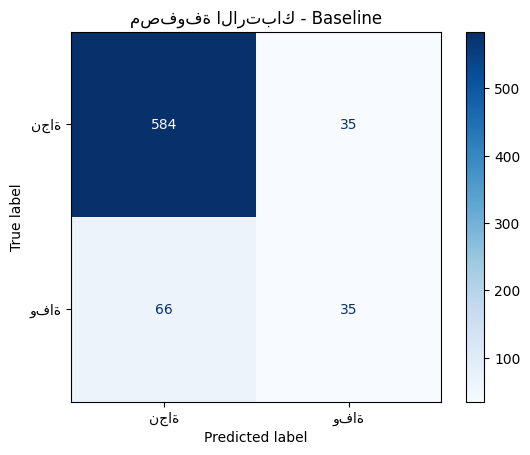

In [ ]:
# الخطوة 4: بناء Pipeline وتدريب نموذج Baseline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# حساب scale_pos_weight من بيانات التدريب
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# إنشاء pipeline
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # تعويض القيم المفقودة بالوسيط
    ('scaler', StandardScaler()),                   # تسليق البيانات
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# تدريب النموذج
print("تدريب النموذج...")
pipeline.fit(X_train, y_train)
print("✅ تم التدريب")

# التنبؤ على مجموعة الاختبار
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# تقييم الأداء
print("\n=== أداء النموذج الأساسي (Baseline) ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nتقرير التصنيف:")
print(classification_report(y_test, y_pred, target_names=['نجاة', 'وفاة']))

# رسم مصفوفة الارتباك
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test,
                                       display_labels=['نجاة', 'وفاة'],
                                       cmap=plt.cm.Blues)
plt.title('مصفوفة الارتباك - Baseline')
plt.show()

scale_pos_weight = 6.16
تدريب النموذج مع SMOTE...
✅ تم التدريب

=== أداء النموذج مع SMOTE ===
AUC-ROC: 0.8264

تقرير التصنيف:
              precision    recall  f1-score   support

        نجاة       0.90      0.91      0.90       619
        وفاة       0.40      0.38      0.39       101

    accuracy                           0.83       720
   macro avg       0.65      0.64      0.64       720
weighted avg       0.83      0.83      0.83       720



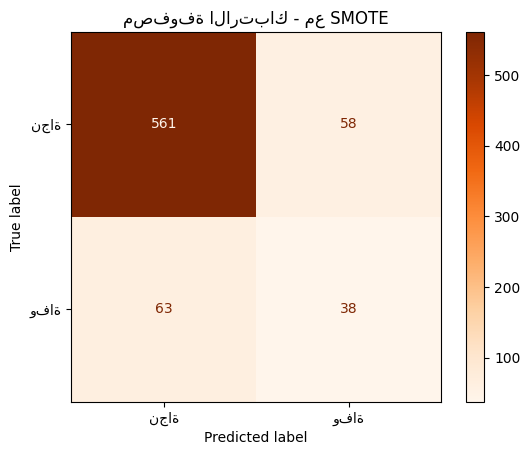

In [ ]:
# الخطوة 5: تحسين النموذج باستخدام SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# إعادة تعريف scale_pos_weight (نفس القيمة)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# إنشاء pipeline مع SMOTE
pipeline_smote = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),               # إضافة SMOTE
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,           # لا يزال نستخدمه مع SMOTE
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# تدريب النموذج
print("تدريب النموذج مع SMOTE...")
pipeline_smote.fit(X_train, y_train)
print("✅ تم التدريب")

# التنبؤ والتقييم
y_pred_smote = pipeline_smote.predict(X_test)
y_pred_proba_smote = pipeline_smote.predict_proba(X_test)[:, 1]

print("\n=== أداء النموذج مع SMOTE ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_smote):.4f}")
print("\nتقرير التصنيف:")
print(classification_report(y_test, y_pred_smote, target_names=['نجاة', 'وفاة']))

# رسم مصفوفة الارتباك
ConfusionMatrixDisplay.from_estimator(pipeline_smote, X_test, y_test,
                                       display_labels=['نجاة', 'وفاة'],
                                       cmap=plt.cm.Oranges)
plt.title('مصفوفة الارتباك - مع SMOTE')
plt.show()

بدء البحث عن أفضل المعاملات (قد يستغرق عدة دقائق)...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ أفضل المعاملات: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
أفضل AUC في Cross-Validation: 0.8523

=== أداء أفضل نموذج بعد الضبط ===
AUC-ROC: 0.8486

تقرير التصنيف:
              precision    recall  f1-score   support

        نجاة       0.90      0.96      0.93       619
        وفاة       0.56      0.34      0.42       101

    accuracy                           0.87       720
   macro avg       0.73      0.65      0.67       720
weighted avg       0.85      0.87      0.86       720



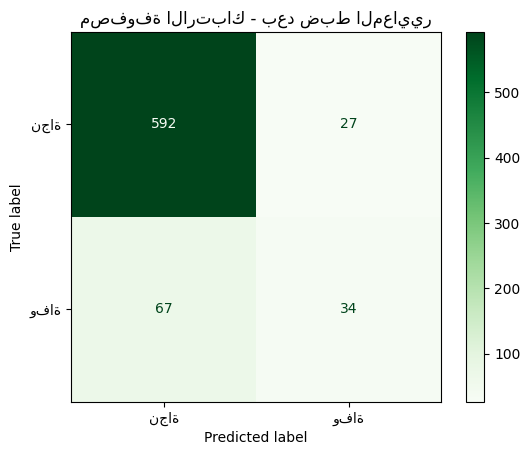

In [ ]:
# الخطوة 6: ضبط المعايير (Hyperparameter Tuning)

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# حساب scale_pos_weight (نفس القيمة)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# إنشاء pipeline أساسي (بدون SMOTE للسرعة)
pipeline_tune = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# تحديد المعاملات المراد تجربتها (مساحة محدودة للسرعة)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# إعداد GridSearchCV مع 3 folds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline_tune,
    param_grid,
    cv=cv,
    scoring='roc_auc',   # نحسن AUC-ROC
    n_jobs=-1,
    verbose=1
)

print("بدء البحث عن أفضل المعاملات (قد يستغرق عدة دقائق)...")
grid_search.fit(X_train, y_train)

print(f"\n✅ أفضل المعاملات: {grid_search.best_params_}")
print(f"أفضل AUC في Cross-Validation: {grid_search.best_score_:.4f}")

# تقييم أفضل نموذج على مجموعة الاختبار
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n=== أداء أفضل نموذج بعد الضبط ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print("\nتقرير التصنيف:")
print(classification_report(y_test, y_pred_best, target_names=['نجاة', 'وفاة']))

# رسم مصفوفة الارتباك
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                       display_labels=['نجاة', 'وفاة'],
                                       cmap=plt.cm.Greens)
plt.title('مصفوفة الارتباك - بعد ضبط المعايير')
plt.show()

أفضل عتبة حسب F1: 0.098
F1 عند هذه العتبة: 0.5252
Precision: 0.4124, Recall: 0.7228

لتحقيق Recall >= 0.6:
  العتبة: 0.117
  Precision: 0.4224, Recall: 0.6733


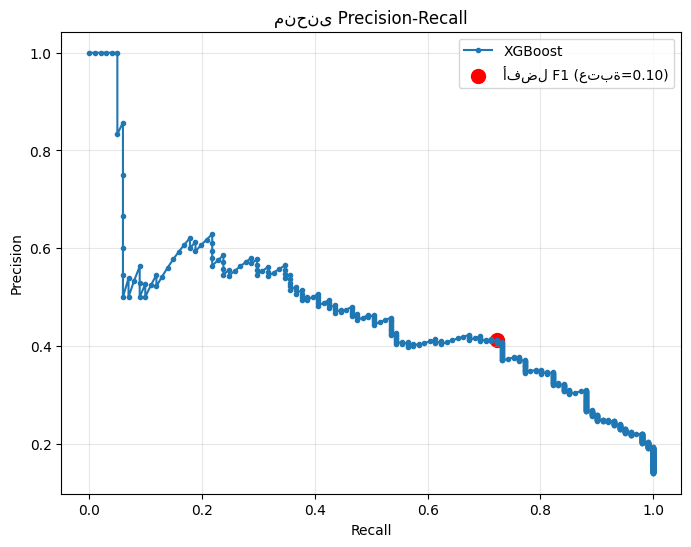


=== الأداء باستخدام العتبة المختارة (0.117) ===
              precision    recall  f1-score   support

        نجاة       0.94      0.85      0.89       619
        وفاة       0.42      0.67      0.52       101

    accuracy                           0.82       720
   macro avg       0.68      0.76      0.71       720
weighted avg       0.87      0.82      0.84       720



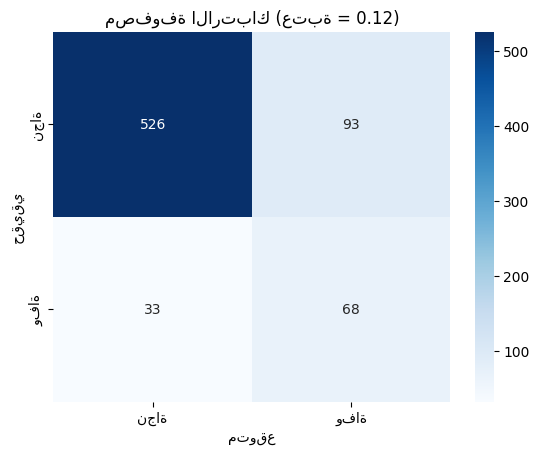

In [7]:
# الخطوة 7: ضبط عتبة القرار (Threshold Tuning)

from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import matplotlib.pyplot as plt

# الحصول على احتمالات التنبؤ من أفضل نموذج
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# حساب precision, recall, f1 لقيم عتبة مختلفة
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# حساب F1-score لكل عتبة
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

# البحث عن أفضل عتبة تزيد F1 (أو يمكننا استهداف Recall معين)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"أفضل عتبة حسب F1: {best_threshold:.3f}")
print(f"F1 عند هذه العتبة: {best_f1:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# إذا أردنا Recall أعلى، نختار عتبة أقل
# مثلاً نبحث عن عتبة تعطي Recall >= 0.6
target_recall = 0.6
valid_indices = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_indices) > 0:
    # نختار أعلى precision بين تلك العتبات
    best_recall_idx = valid_indices[np.argmax(precisions[valid_indices])]
    threshold_high_recall = thresholds[best_recall_idx]
    print(f"\nلتحقيق Recall >= {target_recall}:")
    print(f"  العتبة: {threshold_high_recall:.3f}")
    print(f"  Precision: {precisions[best_recall_idx]:.4f}, Recall: {recalls[best_recall_idx]:.4f}")
else:
    print(f"\nلا توجد عتبة تحقق Recall >= {target_recall}")

# رسم منحنى Precision-Recall
plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, marker='.', label='XGBoost')
plt.scatter(recalls[best_idx], precisions[best_idx], marker='o', color='red', s=100, label=f'أفضل F1 (عتبة={best_threshold:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('منحنى Precision-Recall')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# تطبيق العتبة المختارة (اختر إما best_threshold أو threshold_high_recall)
# سنستخدم العتبة التي تعطي recall أعلى (مثلاً threshold_high_recall إن وجدت)
if len(valid_indices) > 0:
    chosen_threshold = threshold_high_recall
else:
    chosen_threshold = best_threshold

y_pred_adj = (y_pred_proba >= chosen_threshold).astype(int)

print(f"\n=== الأداء باستخدام العتبة المختارة ({chosen_threshold:.3f}) ===")
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_adj, target_names=['نجاة', 'وفاة']))

# رسم مصفوفة الارتباك الجديدة
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_adj)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['نجاة', 'وفاة'], yticklabels=['نجاة', 'وفاة'])
plt.title(f'مصفوفة الارتباك (عتبة = {chosen_threshold:.2f})')
plt.xlabel('متوقع')
plt.ylabel('حقيقي')
plt.show()

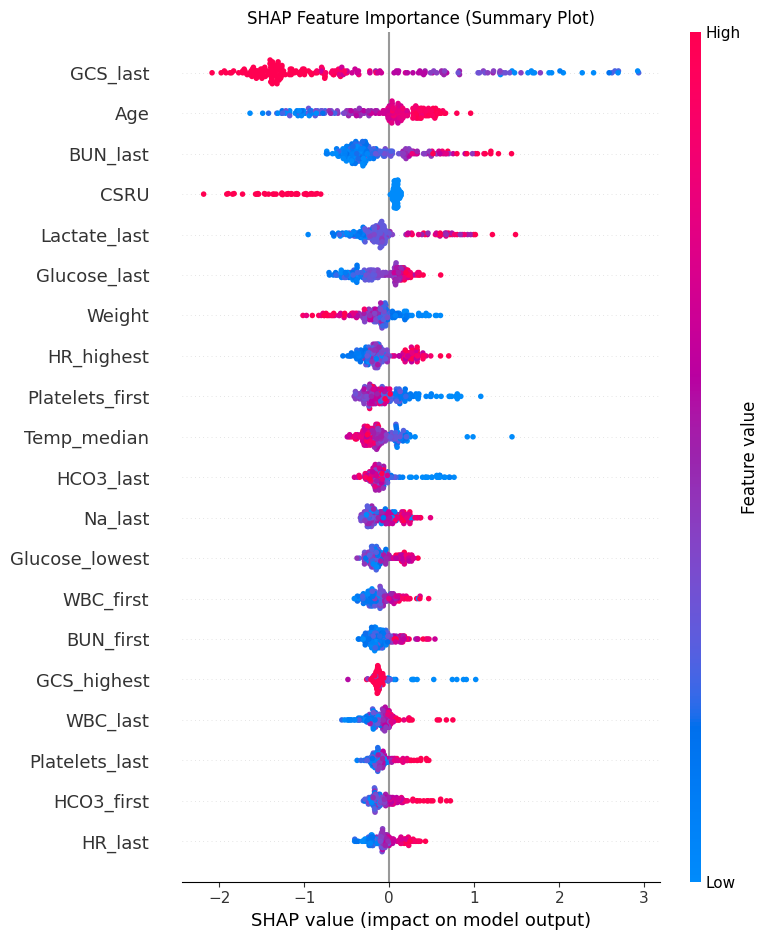

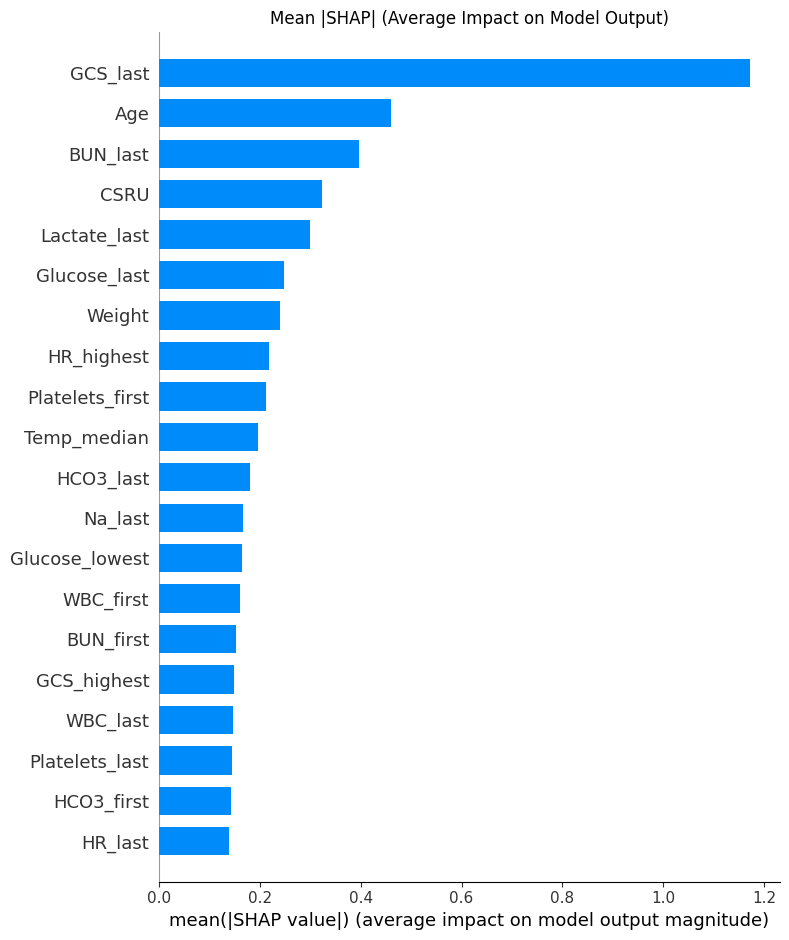

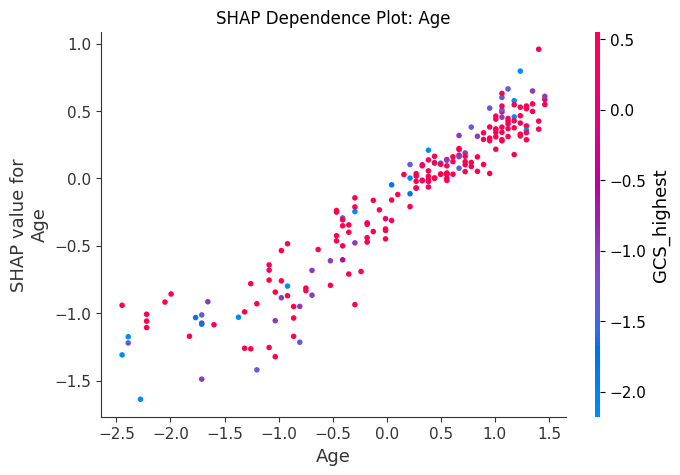

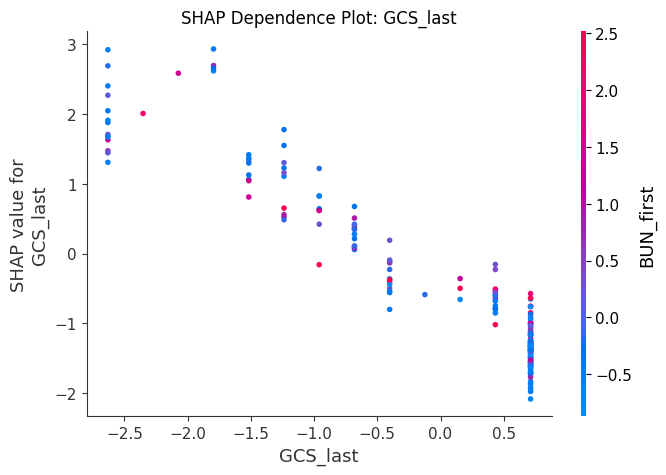


=== أهم 10 ميزات (حسب SHAP) ===
1. GCS_last (متوسط SHAP: 1.1728)
2. Age (متوسط SHAP: 0.4597)
3. BUN_last (متوسط SHAP: 0.3970)
4. CSRU (متوسط SHAP: 0.3231)
5. Lactate_last (متوسط SHAP: 0.2989)
6. Glucose_last (متوسط SHAP: 0.2471)
7. Weight (متوسط SHAP: 0.2404)
8. HR_highest (متوسط SHAP: 0.2191)
9. Platelets_first (متوسط SHAP: 0.2119)
10. Temp_median (متوسط SHAP: 0.1959)


In [8]:
# الخطوة 8: تحليل SHAP لأهمية الميزات

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# استخراج الخطوات من أفضل نموذج
# أفضل نموذج هو best_model من GridSearch (pipeline كامل)
# نحتاج إلى تحويل البيانات بنفس المعالج قبل تمريرها إلى SHAP

# تطبيق المعالجة المسبقة (imputer + scaler) على بيانات الاختبار
# يمكننا الوصول إلى الخطوات من خلال best_model.named_steps
preprocessor = best_model.named_steps['imputer']  # SimpleImputer
scaler = best_model.named_steps['scaler']        # StandardScaler
classifier = best_model.named_steps['classifier'] # XGBClassifier

# تحويل X_test
X_test_imputed = preprocessor.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# استخدام SHAP (نأخذ عينة عشوائية للسرعة)
X_sample = X_test_processed.sample(n=min(200, len(X_test_processed)), random_state=42)

# إنشاء explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)

# 1. رسم Summary Plot (أهم 20 ميزة)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=X_sample.columns, max_display=20, show=False)
plt.title('SHAP Feature Importance (Summary Plot)')
plt.tight_layout()
plt.show()

# 2. رسم Bar Plot (متوسط القيمة المطلقة لـ SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=X_sample.columns, plot_type="bar", max_display=20, show=False)
plt.title('Mean |SHAP| (Average Impact on Model Output)')
plt.tight_layout()
plt.show()

# 3. (اختياري) رسم dependence plot لأهم ميزتين
top_features = np.argsort(np.mean(np.abs(shap_values), axis=0))[-2:]
for idx in top_features:
    feature_name = X_sample.columns[idx]
    shap.dependence_plot(idx, shap_values, X_sample, feature_names=X_sample.columns, show=False)
    plt.title(f'SHAP Dependence Plot: {feature_name}')
    plt.show()

# طباعة أهم 10 ميزات
mean_shap = np.mean(np.abs(shap_values), axis=0)
top_indices = np.argsort(mean_shap)[-10:][::-1]
print("\n=== أهم 10 ميزات (حسب SHAP) ===")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. {X_sample.columns[idx]} (متوسط SHAP: {mean_shap[idx]:.4f})")

In [9]:
# الخطوة 9: حفظ النموذج

import joblib

# حفظ أفضل نموذج (بعد الضبط)
joblib.dump(best_model, 'icu_mortality_best_model.pkl')
print("✅ تم حفظ النموذج في 'icu_mortality_best_model.pkl'")

# حفظ المعالج (preprocessor) بشكل منفصل (اختياري)
preprocessor = best_model.named_steps['imputer']  # SimpleImputer
scaler = best_model.named_steps['scaler']        # StandardScaler
joblib.dump({'imputer': preprocessor, 'scaler': scaler}, 'preprocessor.pkl')
print("✅ تم حفظ المعالج في 'preprocessor.pkl'")

✅ تم حفظ النموذج في 'icu_mortality_best_model.pkl'
✅ تم حفظ المعالج في 'preprocessor.pkl'
